**Introducción a la Ciencia de Datos 2026**  
Posgrado en Ciencias de la Computación - CICESE  
Dr. Irvin Hussein López Nava

## ICD - 2: Datos

Sesión 2 del curso. Diapositivas: [ICD - 2 Datos.pdf](https://github.com/husseinlopez/icd2026/blob/main/clases/ICD%20-%202%20Datos.pdf)

En clase revisamos qué es un dato, cómo se clasifica según su naturaleza y su escala de medición (nominal, ordinal, intervalo y razón), y qué significa un tipo de dato desde el punto de vista de la computadora. Este notebook lleva esas ideas al código.

Recorremos tres cosas: lo mínimo para movernos en Jupyter, la carga e inspección de un conjunto de datos tabular, y los tipos que ofrece Python. Usamos `weather.numeric`, el mismo dataset de las diapositivas. Lo que interesa es llegar a la distancia que hay entre el tipo con el que una columna se almacena y la escala con la que se midió.

---

### Jupyter

Un notebook son celdas de texto y celdas de código. Shift + Enter ejecuta la celda actual.

Aquí vemos lo mínimo para trabajar. La actividad asíncrona de la [clase 1](https://github.com/husseinlopez/icd2026/blob/main/clases/ICD%20-%201%20Intro.pdf), los notebooks 01.00 a 01.08 del libro, cubre IPython y Jupyter a detalle.

In [1]:
print("Hola mundo")

Hola mundo


Si la última línea es una expresión, se muestra su valor sin `print`.

In [2]:
2 + 3

5

Las variables sobreviven entre celdas mientras el kernel siga vivo, así que importa el orden en que las ejecutamos, no el orden en que aparecen.

In [3]:
x = 10
x * 5

50

Un signo de interrogación después de cualquier nombre abre su documentación.

In [4]:
len?

### El dataset

`weather.numeric` es un conjunto clásico (Quinlan, 1986; viene con Weka): 14 días descritos por el clima y si se jugó o no. El archivo CSV debe estar en la misma carpeta que este notebook.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("weather.numeric.csv")
df

,Day,Outlook,Temperature,Humidity,Wind,Play
0,1,sunny,85,85,weak,False
1,2,sunny,80,90,strong,False
2,3,overcast,83,86,weak,True
3,4,rain,70,96,weak,True
4,5,rain,68,80,weak,True
5,6,rain,65,70,strong,False
6,7,overcast,64,65,strong,True
7,8,sunny,72,95,weak,False
8,9,sunny,69,70,weak,True
9,10,rain,75,80,weak,True


14 filas y 6 columnas.

In [7]:
df.shape

(14, 6)

Cada fila es una **instancia**.

In [8]:
df.loc[0]

Day                1
Outlook        sunny
Temperature       85
Humidity          85
Wind            weak
Play           False
Name: 0, dtype: object

Cada columna es un **atributo**.

In [9]:
df["Temperature"]

0     85
1     80
2     83
3     70
4     68
5     65
6     64
7     72
8     69
9     75
10    75
11    72
12    81
13    71
Name: Temperature, dtype: int64

### Tipos de datos del dataset

pandas le asignó un tipo a cada columna a partir de lo que encontró en el archivo.

In [10]:
df.dtypes

Day            int64
Outlook          str
Temperature    int64
Humidity       int64
Wind             str
Play            bool
dtype: object

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Day          14 non-null     int64
 1   Outlook      14 non-null     str  
 2   Temperature  14 non-null     int64
 3   Humidity     14 non-null     int64
 4   Wind         14 non-null     str  
 5   Play         14 non-null     bool 
dtypes: bool(1), int64(3), str(2)
memory usage: 706.0 bytes


Vale la pena comparar esos tipos con las escalas de medición:

| Columna | Escala | Tipo en pandas |
|---|---|---|
| Day | identificador, no es una variable | `int64` |
| Outlook | nominal | texto |
| Temperature | intervalo (°F) | `int64` |
| Humidity | razón (%) | `int64` |
| Wind | ordinal, weak < strong | texto |
| Play | nominal binaria, es la variable objetivo | `bool` |

Day, Temperature y Humidity comparten el tipo `int64` y no significan lo mismo. Wind tiene un orden y pandas la trata como texto igual que Outlook. El tipo describe cómo se almacena el dato en memoria; la escala describe qué se puede hacer con él, y eso no está en el archivo.

(En pandas 2 las columnas de texto aparecen como `object`; desde pandas 3, como `str`.)

### Descripción de los datos

`describe()` resume las columnas numéricas.

In [12]:
df.describe()

,Day,Temperature,Humidity
count,14.0000,14.000000,14.000000
mean,7.5000,73.571429,81.642857
std,4.1833,6.571667,10.285218
min,1.0000,64.000000,65.000000
25%,4.2500,69.250000,71.250000
50%,7.5000,72.000000,82.500000
75%,10.7500,78.750000,90.000000
max,14.0000,85.000000,96.000000


Incluyó a Day, que no tiene sentido promediar. Para las demás columnas hay que pedirlo explícitamente.

In [13]:
df.describe(include=["object", "bool"])

/tmp/ipykernel_474/3870744420.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=["object", "bool"])


,Outlook,Wind,Play
count,14,14,14
unique,3,2,2
top,sunny,weak,True
freq,5,8,9


In [14]:
df["Outlook"].value_counts()

Outlook
sunny       5
rain        5
overcast    4
Name: count, dtype: int64

### Gráficas

Un histograma por cada columna numérica.

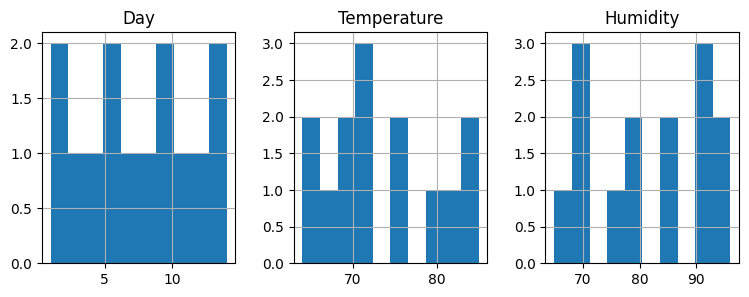

In [15]:
df.hist(figsize=(9, 3), layout=(1, 3))
plt.show()

Otra vez Day: pandas la graficó porque es `int64`. El histograma de un identificador no dice nada, y solo nosotros sabemos que hay que ignorarlo.

Para los atributos cualitativos, la proporción de cada categoría.

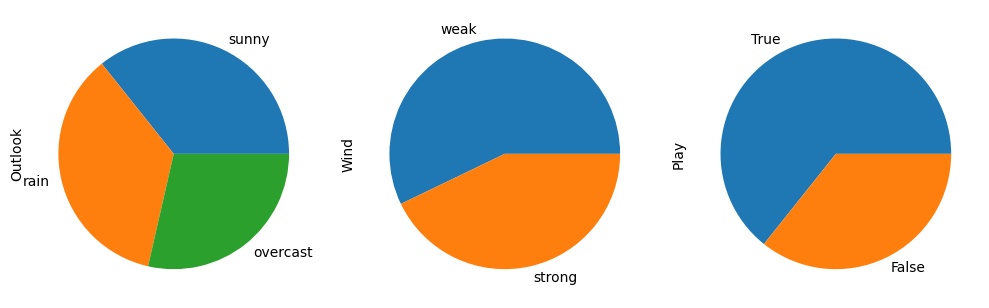

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, col in zip(axes, ["Outlook", "Wind", "Play"]):
    df[col].value_counts().plot(kind="pie", ax=ax, ylabel=col)
plt.tight_layout()
plt.show()

### Tipos de datos de Python

`type()` devuelve el tipo de cualquier valor.

Numéricos: `int`, `float`, `complex`. `bool` es internamente un `int`.

In [17]:
a = 5
b = 5.0
c = 2 + 3j
print(type(a), type(b), type(c))
print(a == b, type(a) == type(b))
print(type(True), True + True)

<class 'int'> <class 'float'> <class 'complex'>
True False
<class 'bool'> 2


Texto: `str`. Es una secuencia, así que se indexa y se rebana.

In [18]:
s = "Ciencia de Datos"
print(type(s), len(s))
print(s[0], s[-1], s[:7])
print(s.upper(), s.split())

<class 'str'> 16
C s Ciencia
CIENCIA DE DATOS ['Ciencia', 'de', 'Datos']


Listas y tuplas guardan secuencias ordenadas. La lista se modifica, la tupla no.

In [19]:
lista = ["intro", "datos", "ciencia"]
tupla = ("intro", "datos", "ciencia")
print(type(lista), type(tupla))

lista[0] = "Intro"
lista.append(2026)
print(lista)

print(tupla[0], tupla[-1])
# tupla[0] = "Intro"   # TypeError: la tupla es inmutable

<class 'list'> <class 'tuple'>
['Intro', 'datos', 'ciencia', 2026]
intro ciencia


Los conjuntos no admiten duplicados ni orden. Los diccionarios guardan pares clave-valor.

In [20]:
conjunto = {"intro", "datos", "ciencia", "datos"}
print(type(conjunto), conjunto, "datos" in conjunto)

persona = {"nombre": "Hussein", "edad": 24, "cursos": ["ICD", "ML"]}
persona["semestre"] = 1
print(type(persona), persona["nombre"], persona)

<class 'set'> {'ciencia', 'intro', 'datos'} True
<class 'dict'> Hussein {'nombre': 'Hussein', 'edad': 24, 'cursos': ['ICD', 'ML'], 'semestre': 1}


Otros tipos que irán apareciendo:

In [21]:
for valor in [None, range(5), b"bytes", frozenset({1, 2})]:
    print(type(valor).__name__, "->", valor)

NoneType -> None
range -> range(0, 5)
bytes -> b'bytes'
frozenset -> frozenset({1, 2})


Y los tipos con los que trabajamos hoy:

In [22]:
print(type(df))
print(type(df["Temperature"]))
print(type(df["Temperature"][0]))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>
<class 'numpy.int64'>


El DataFrame es un conjunto de Series, y un entero dentro de una Serie no es el `int` de Python sino un `numpy.int64`. Por qué, y por qué eso importa, es el tema de la siguiente sesión.

### Actividad

Clasifiquen las columnas del dataset Titanic por escala de medición:

`PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked`

Dos son identificadores, una es ordinal guardada como entero y una es la variable objetivo.

---

### Declaración de uso de IA generativa

Este notebook parte del que se usó en la edición anterior del curso. Se utilizó Claude (Anthropic) para sintetizar el contenido duplicado y reordenar las secciones.

### Referencias

- VanderPlas, J. (2022). *Python Data Science Handbook*, 2a ed., Parte I. https://jakevdp.github.io/PythonDataScienceHandbook/
- Tipos integrados de Python: https://docs.python.org/3/library/stdtypes.html
- Quinlan, J. R. (1986). Induction of decision trees. *Machine Learning*, 1(1), 81-106.